Exctract Data from Excel file into .csv

In [20]:
import pandas as pd

# Load the Excel file
#excel_file = r"C:\Users\Alif Haidar\OneDrive\Desktop\42879 - Decision Support and Strategic Assesment\Group 49 - ELECTRE.xlsx"
excel_file = "Group 49 - ELECTRE.xlsx"
# Define the sheet names you want to extract
sheets = ["Electre csv", "Ranking csv"]

# Loop through sheets and save each as a CSV
for sheet in sheets:
    # Read the sheet
    df = pd.read_excel(excel_file, sheet_name=sheet)
    
    # Create a filename based on the sheet name
    csv_filename = f"{sheet}.csv"
    
    # Save to CSV
    df.to_csv(csv_filename, index=False)
    print(f"Saved {csv_filename}")


Saved Electre csv.csv
Saved Ranking csv.csv


Create Concordance and Discordance Matrix

In [21]:
import pandas as pd
import numpy as np

# Load the CSVs
electre_df = pd.read_csv("Electre csv.csv")
weights_df = pd.read_csv("Ranking csv.csv")

# Extract criteria and weights
criteria = list(weights_df["Scenarios"])
weights = dict(zip(weights_df["Scenarios"], weights_df["Weight"]))
total_weight = sum(weights.values())

# Keep only relevant numeric columns for evaluation
performance = electre_df[criteria]
scenarios = electre_df["Scenarios"].values

# define treshold
t_i = 2.5

# --- Concordance Matrix ---
def concordance_matrix():
    n = len(scenarios)
    C = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            if i != j:
                # Criteria where i is >= j
                J = [crit for crit in criteria if performance.loc[i, crit] >= performance.loc[j, crit]]
                w_sum = sum(weights[crit] for crit in J)
                C[i, j] = w_sum / total_weight
    return pd.DataFrame(C, index=scenarios, columns=scenarios)

# --- Discordance Matrix ---
def discordance_matrix():
    n = len(scenarios)
    D = np.zeros((n, n))
    
    # thresholds t_i = (max - min) for each criterion
    thresholds = t_i
    
    for i in range(n):
        for j in range(n):
            if i != j:
                # Check if any criterion exceeds threshold
                violated = False
                for crit in criteria:
                    if (performance.loc[j, crit] - performance.loc[i, crit]) > thresholds:
                        violated = True
                        break
                D[i, j] = 1 if violated else 0
    return pd.DataFrame(D, index=scenarios, columns=scenarios)

# Compute matrices
C_matrix = concordance_matrix()
D_matrix = discordance_matrix()

# Save results
C_matrix.to_csv("Concordance_Matrix.csv")
D_matrix.to_csv("Discordance_Matrix.csv")

print("Concordance Matrix:\n", C_matrix)
print("\nDiscordance Matrix:\n", D_matrix)

Concordance Matrix:
            SC1       SC3       SC9      SC10      SC11      SC12      SC13  \
SC1   0.000000  0.696970  0.636364  0.696970  0.696970  0.696970  0.696970   
SC3   0.424242  0.000000  0.484848  0.484848  0.878788  0.757576  0.696970   
SC9   0.363636  0.575758  0.000000  0.696970  0.696970  0.636364  0.575758   
SC10  0.545455  0.696970  0.757576  0.000000  0.696970  0.757576  0.575758   
SC11  0.303030  0.636364  0.484848  0.484848  0.000000  0.515152  0.575758   
SC12  0.363636  0.636364  0.484848  0.484848  0.878788  0.000000  0.757576   
SC13  0.424242  0.484848  0.484848  0.484848  0.727273  0.424242  0.000000   
SC16  0.363636  0.515152  0.484848  0.363636  0.878788  0.696970  0.575758   
SC18  1.000000  0.696970  1.000000  0.878788  0.696970  0.696970  0.696970   
SC20  0.818182  0.878788  0.757576  1.000000  0.878788  0.939394  0.757576   

          SC16      SC18      SC20  
SC1   0.696970  0.454545  0.696970  
SC3   0.939394  0.424242  0.303030  
SC9   0.7

Build the Outranking Graph

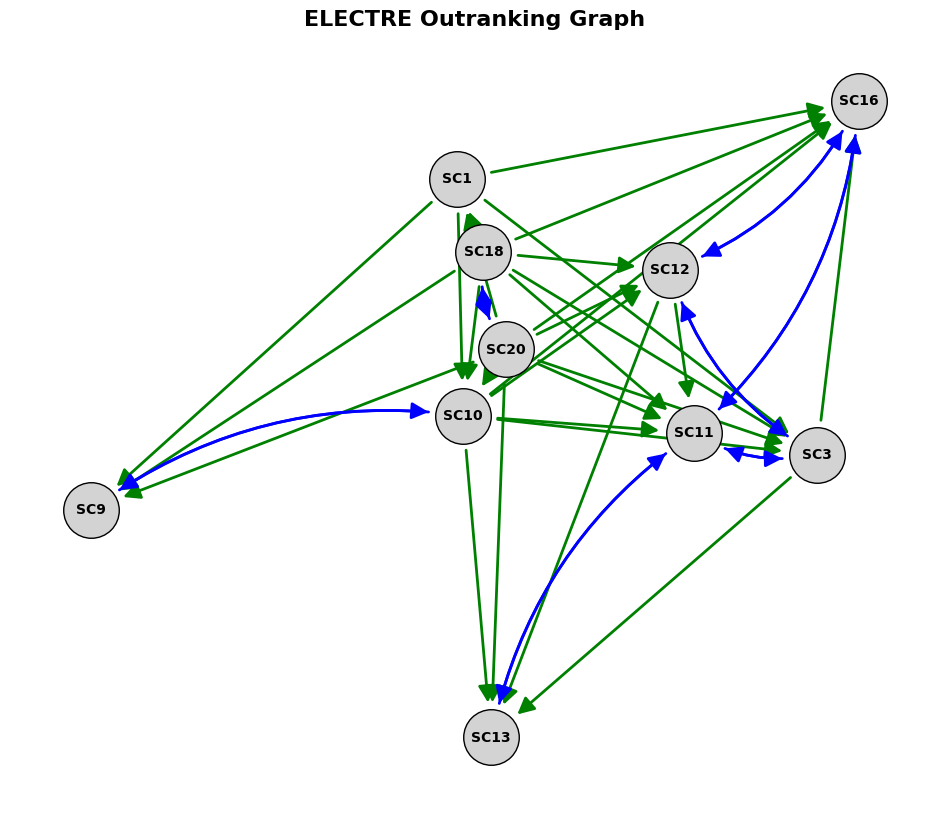

In [22]:
import networkx as nx
import matplotlib.pyplot as plt

# --- Load the matrices ---
C_matrix = pd.read_csv("Concordance_Matrix.csv", index_col=0)
D_matrix = pd.read_csv("Discordance_Matrix.csv", index_col=0)
scenarios = C_matrix.index.tolist()

# --- User-defined thresholds ---
# You can set them manually or compute defaults (mean values)
C_threshold = float(input("Enter Concordance threshold C* (suggested default {:.2f}): ".format(C_matrix.values.mean())))
D_threshold = float(input("Enter Discordance threshold D* (suggested default {:.2f}): ".format(D_matrix.values.mean())))

# --- Build outranking relation ---
n = len(scenarios)
relations = []

for i in range(n):
    for j in range(n):
        if i != j:
            if C_matrix.iloc[i, j] > C_threshold and D_matrix.iloc[i, j] < D_threshold:
                if C_matrix.iloc[j, i] > C_threshold and D_matrix.iloc[j, i] < D_threshold:
                    relations.append((scenarios[i], scenarios[j], "indifference"))
                    relations.append((scenarios[j], scenarios[i], "indifference"))
                else:
                    relations.append((scenarios[i], scenarios[j], "outranks"))
            elif C_matrix.iloc[j, i] > C_threshold and D_matrix.iloc[j, i] < D_threshold:
                relations.append((scenarios[j], scenarios[i], "outranks"))
            else:
                relations.append((scenarios[i], scenarios[j], "incomparable"))

# --- Create graph ---
G = nx.DiGraph()

for rel in relations:
    a, b, rel_type = rel
    if rel_type == "outranks":
        G.add_edge(a, b, relation="outranks")
    elif rel_type == "indifference":
        G.add_edge(a, b, relation="indifference")
        G.add_edge(b, a, relation="indifference")

# --- Draw graph ---
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42, k=0.6)

# Separate edge types
outrank_edges = [(u, v) for u, v, d in G.edges(data=True) if d["relation"] == "outranks"]
indiff_edges = set(tuple(sorted((u, v))) for u, v, d in G.edges(data=True) if d["relation"] == "indifference")

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=1600, node_color="lightgray", edgecolors="black")
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

# Draw outranking edges (with arrowhead offset)
nx.draw_networkx_edges(
    G, pos,
    edgelist=outrank_edges,
    edge_color="green",
    arrows=True,
    arrowsize=25,        # Bigger arrowheads
    width=2,
    min_target_margin=25,  # Add distance from node
    min_source_margin=25
)

# Draw indifference edges (double arrows, slightly curved, spaced out)
for (u, v) in indiff_edges:
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v)],
        edge_color="blue",
        arrows=True,
        arrowsize=25,
        width=2,
        min_target_margin=25,
        min_source_margin=25,
        connectionstyle="arc3,rad=0.2"
    )
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(v, u)],
        edge_color="blue",
        arrows=True,
        arrowsize=25,
        width=2,
        min_target_margin=25,
        min_source_margin=25,
        connectionstyle="arc3,rad=-0.2"
    )

plt.title("ELECTRE Outranking Graph", fontsize=16, fontweight="bold")
plt.axis("off")
plt.show()

Identify top 4 Scenarios

In [23]:
# --- Load outranking graph built earlier ---
C_matrix = pd.read_csv("Concordance_Matrix.csv", index_col=0)
D_matrix = pd.read_csv("Discordance_Matrix.csv", index_col=0)
scenarios = C_matrix.index.tolist()

# Assume we already have the graph G from the previous step
# G is a DiGraph with "relation" attribute on edges

# --- Compute outranking strengths ---
outrank_scores = {}
for node in G.nodes():
    out_degree = sum(1 for _, _, d in G.out_edges(node, data=True) if d["relation"] == "outranks")
    in_degree = sum(1 for _, _, d in G.in_edges(node, data=True) if d["relation"] == "outranks")
    net_flow = out_degree - in_degree
    outrank_scores[node] = {"outranks": out_degree, "outranked_by": in_degree, "net_flow": net_flow}

# --- Convert to DataFrame for sorting ---
ranking_df = pd.DataFrame.from_dict(outrank_scores, orient="index")
ranking_df = ranking_df.sort_values(by="net_flow", ascending=False)

# --- Get top 4 ---
top4 = ranking_df.head(4)

print("Top 4 Scenarios based on ELECTRE Outranking:")
print(top4)

# Optionally save results
ranking_df.to_csv("ELECTRE_Ranking.csv")


Top 4 Scenarios based on ELECTRE Outranking:
      outranks  outranked_by  net_flow
SC20         8             0         8
SC18         7             0         7
SC10         5             3         2
SC1          4             2         2
